# STATISTICAL ANALYSIS ON PENGUINS
- Making hypothesis and testing the claim

Here we cover
```
1 sample t-test
2 sample t-test
1 way anova
correlation signifincance test
variance test
```

## Load the data
- Here I load the penguins dataset directly from seaborn's built-in datasets

In [6]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# We load the penguins dataset from seaborn, and drop rows with missing values
# so we have clean, usable data types (similar to loading the cleaned pickle in step1)

df = sns.load_dataset('penguins')
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [8]:
# df = df.dropna()
# df = df.reset_index(drop=True)

df = df.dropna().reset_index(drop=True)

In [4]:
# print 10 sample values

print(df.sample(10))

       species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
249     Gentoo     Biscoe            42.6           13.7              213.0   
10      Adelie  Torgersen            36.6           17.8              185.0   
57      Adelie     Biscoe            41.1           18.2              192.0   
276     Gentoo     Biscoe            54.3           15.7              231.0   
123     Adelie  Torgersen            44.1           18.0              210.0   
185  Chinstrap      Dream            53.5           19.9              205.0   
51      Adelie     Biscoe            40.6           18.8              193.0   
188  Chinstrap      Dream            50.9           19.1              196.0   
214     Gentoo     Biscoe            46.1           13.2              211.0   
101     Adelie     Biscoe            38.2           20.0              190.0   

     body_mass_g     sex  
249       4950.0  Female  
10        3700.0  Female  
57        4050.0    Male  
276       5650.0    Ma

In [5]:
print(df.describe())

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      333.000000     333.000000         333.000000   333.000000
mean        43.992793      17.164865         200.966967  4207.057057
std          5.468668       1.969235          14.015765   805.215802
min         32.100000      13.100000         172.000000  2700.000000
25%         39.500000      15.600000         190.000000  3550.000000
50%         44.500000      17.300000         197.000000  4050.000000
75%         48.600000      18.700000         213.000000  4775.000000
max         59.600000      21.500000         231.000000  6300.000000


In [6]:
# lets see data types and memory usage

print(df.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 71.9 KB
None


In [7]:
# Memory usage of each column in Bytes

print(df.memory_usage())

Index                 132
species              2664
island               2664
bill_length_mm       2664
bill_depth_mm        2664
flipper_length_mm    2664
body_mass_g          2664
sex                  2664
dtype: int64


# Simple Hypothesis Testing

### Problem (One-sample t-test)
- We are given a sample of penguins with a **sample mean** body mass of about 4207 grams. Determine whether the **population mean** body mass is significantly different from 4000 grams at a **significance level of α = 0.05**.

### Hypothesis (MOST IMPORTANT)
- **Null hypothesis (H0)**: The true average body mass = 4000 g
- **Alternative hypothesis (H1)**: The true average body mass is NOT 4000 g

This is a two-tailed test.


#### Definition
**p_value**: Probability of observing this statistic if the null hypothesis is true

### Prompt used for AI to generate above code:


I have penguin body measurement data (Palmer Penguins, via seaborn). The output of print(df.describe()) is given by following:
```
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      333.000000     333.000000         333.000000   333.000000
mean        43.992793      17.164865         200.966967  4207.057057
std          5.468668       1.969235          14.015765   805.215802
min         32.100000      13.100000         172.000000  2700.000000
25%         39.500000      15.600000         190.000000  3550.000000
50%         44.500000      17.300000         197.000000  4050.000000
75%         48.600000      18.700000         213.000000  4775.000000
max         59.600000      21.500000         231.000000  6300.000000
```


### PROMPT to solve above Problem statement.
We are given a sample of penguins with a sample mean body mass of about 4207 grams. Determine whether the population mean body mass is significantly different from 4000 grams at a significance level of α = 0.05.

Give me code to answer above question

In [10]:
# step1: Get the sample

sample = df['body_mass_g']

print("Sample Mean:", sample.mean())
print("Size of sample:", len(sample))

Sample Mean: 4207.057057057057
Size of sample: 333


Here since:

- Population standard deviation is unknown
- Sample size = 333
- Data is numerical and approximately normal (large n)

We will use One-sample t-test is appropriate

In [13]:
print(list(sample))

[3750.0, 3800.0, 3250.0, 3450.0, 3650.0, 3625.0, 4675.0, 3200.0, 3800.0, 4400.0, 3700.0, 3450.0, 4500.0, 3325.0, 4200.0, 3400.0, 3600.0, 3800.0, 3950.0, 3800.0, 3800.0, 3550.0, 3200.0, 3150.0, 3950.0, 3250.0, 3900.0, 3300.0, 3900.0, 3325.0, 4150.0, 3950.0, 3550.0, 3300.0, 4650.0, 3150.0, 3900.0, 3100.0, 4400.0, 3000.0, 4600.0, 3425.0, 3450.0, 4150.0, 3500.0, 4300.0, 3450.0, 4050.0, 2900.0, 3700.0, 3550.0, 3800.0, 2850.0, 3750.0, 3150.0, 4400.0, 3600.0, 4050.0, 2850.0, 3950.0, 3350.0, 4100.0, 3050.0, 4450.0, 3600.0, 3900.0, 3550.0, 4150.0, 3700.0, 4250.0, 3700.0, 3900.0, 3550.0, 4000.0, 3200.0, 4700.0, 3800.0, 4200.0, 3350.0, 3550.0, 3800.0, 3500.0, 3950.0, 3600.0, 3550.0, 4300.0, 3400.0, 4450.0, 3300.0, 4300.0, 3700.0, 4350.0, 2900.0, 4100.0, 3725.0, 4725.0, 3075.0, 4250.0, 2925.0, 3550.0, 3750.0, 3900.0, 3175.0, 4775.0, 3825.0, 4600.0, 3200.0, 4275.0, 3900.0, 4075.0, 2900.0, 3775.0, 3350.0, 3325.0, 3150.0, 3500.0, 3450.0, 3875.0, 3050.0, 4000.0, 3275.0, 4300.0, 3050.0, 4000.0, 3325.0,

In [9]:
# step2) This is 1 sample. Calculate p_value
from scipy.stats import ttest_1samp

mu_0 = 4000 # # Hypothesized population mean
t_stat, p_value = ttest_1samp(sample, mu_0)

print("T-statistics:", t_stat)
print("p_value     :", p_value)

T-statistics: 4.692452278984732
p_value     : 3.9524431953160015e-06


## What the p-value actually means
### The p-value is the probability (0.0004% ) of observing a sample mean this far away(or farther) from true mean (4000)  if the true mean really were 4000 (i.e. If H0 is true).

In [10]:
# step3: Decide

alpha = 0.05

if p_value < alpha:
    print("Reject H0: Average body mass is significantly different from 4000")
else:
    print("Fail to reject H0: No significant difference from 4000")

Reject H0: Average body mass is significantly different from 4000


## Report
There is strong statistical evidence to conclude that the population mean body mass is significantly different from 4000 g at the 5% significance level.

The positive t-statistic indicates that the sample mean body mass is higher than 4000 g, suggesting that the true population mean body mass is likely greater than 4000 g.

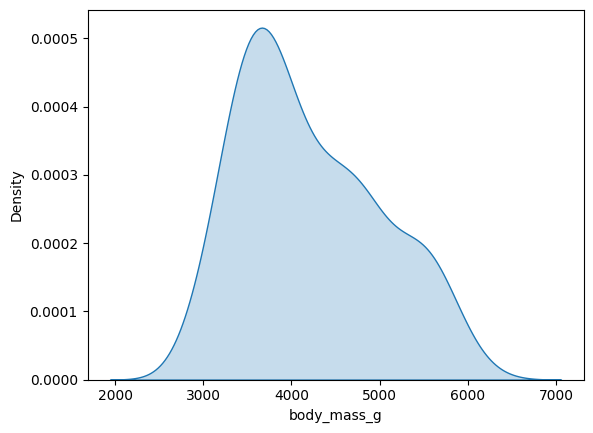

In [11]:
# Plot the KDE
sns.kdeplot(data=df, x='body_mass_g', fill=True)

# Display the plot
plt.show()

## Two-sample t-test

### Question:
- Determine whether the average body mass differs between Adelie and Gentoo penguins. To answer this question, perform a hypothesis test at a **significance level of α = 0.05**.

A two-tailed independent two-sample t-test at α = 0.05 would be used to test whether the mean body mass of Adelie penguins differs from that of Gentoo penguins.

### Define the hypothesis (MOST IMPORTANT)
- **Null hypothesis (H0)**: The true average body mass of Adelie = true average body mass of Gentoo penguins.
- **Alternative hypothesis (H1)**: The true average body mass of Adelie and Gentoo penguins is not same.

This is a two-tailed test.

In [18]:
sample_adelie = df[df['species'] == 'Adelie']['body_mass_g']
sample_gentoo = df[df['species'] == 'Gentoo']['body_mass_g']

print("Adelie body_mass:", list(sample_adelie)[:10])
print("Gentoo body_mass:", list(sample_gentoo)[:10])
print("Mean of Adelie body_mass:", sample_adelie.mean())
print("Mean of Gentoo body_mass:", sample_gentoo.mean())


Mean of Adelie body_mass: 3706.1643835616437
Mean of Gentoo body_mass: 5092.436974789916


In [23]:
print("sample_adelie.describe():\n" sample_adelie.describe())
print("sample_gentoo.describe():\n", sample_gentoo.describe())

sample_adelie.describe():
 count     146.000000
mean     3706.164384
std       458.620135
min      2850.000000
25%      3362.500000
50%      3700.000000
75%      4000.000000
max      4775.000000
Name: body_mass_g, dtype: float64
sample_gentoo.describe():
 count     119.000000
mean     5092.436975
std       501.476154
min      3950.000000
25%      4700.000000
50%      5050.000000
75%      5500.000000
max      6300.000000
Name: body_mass_g, dtype: float64


### Prompt used for AI to generate above code:

I have penguin body measurement data. The output of 
print("sample_adelie.describe():\n" sample_adelie.describe())
print("sample_gentoo.describe():\n", sample_gentoo.describe())
is given by following:
```
sample_adelie.describe():
 count     146.000000
mean     3706.164384
std       458.620135
min      2850.000000
25%      3362.500000
50%      3700.000000
75%      4000.000000
max      4775.000000
Name: body_mass_g, dtype: float64
sample_gentoo.describe():
 count     119.000000
mean     5092.436975
std       501.476154
min      3950.000000
25%      4700.000000
50%      5050.000000
75%      5500.000000
max      6300.000000
Name: body_mass_g, dtype: float64
```

### Problem statement.
Determine whether the average body mass differs between Adelie and Gentoo penguins. To answer this question, perform a hypothesis test at a significance level of α = 0.05.

Give me code to answer above question

In [12]:
# step1: Display mean, std_dev, count for penguin body mass by species

df.groupby('species', observed=True)['body_mass_g'].agg(['mean', 'std', 'count'])

# Observ: The sample mean body mass for Gentoo is ~5092g and for Adelie is ~3706g

,mean,std,count
species,,,
Adelie,3706.164384,458.620135,146
Chinstrap,3733.088235,384.335081,68
Gentoo,5092.436975,501.476154,119


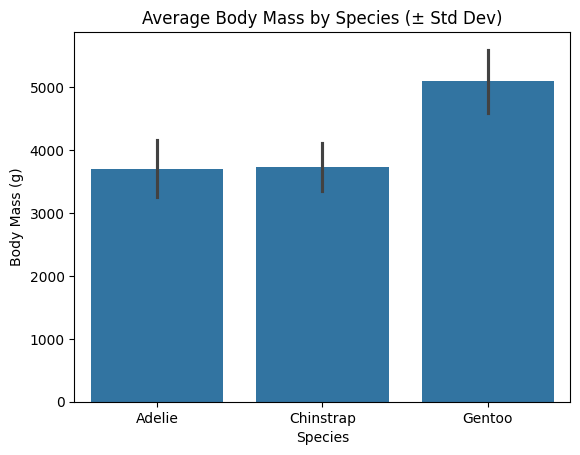

In [11]:
# step2: Let see the average body mass of penguins across species
sns.barplot(
    data=df,
    x="species",
    y="body_mass_g",
    errorbar="sd"
)

plt.title("Average Body Mass by Species (± Std Dev)")
plt.ylabel("Body Mass (g)")
plt.xlabel("Species")
plt.show()

# observ: Gentoo penguins have a much higher mean body mass.
# The variability, AKA STD_dev, differs somewhat across species

In [12]:
# step3: calculate the t_stat and p_value (Welch's t-test)

sample_adelie = df[df['species'] == 'Adelie']['body_mass_g']
sample_gentoo = df[df['species'] == 'Gentoo']['body_mass_g']

In [13]:
# step4) Look at sample size and variablility
print("Samples of Adelie:", sample_adelie[:5].to_list())   # first 5 samples only
print("Samples of Gentoo:", sample_gentoo[:5].to_list())   # first 5 samples only

print("size of sample_adelie:", len(sample_adelie))
print("size of sample_gentoo:", len(sample_gentoo))

# Adelie and Gentoo penguin samples:
# - Have different sample sizes
# - Have slighly different body mass variability
# - Therefore, Welch's t-test (equal_var=False) is the statistically safer choice

Samples of Adelie: [3750.0, 3800.0, 3250.0, 3450.0, 3650.0]
Samples of Gentoo: [4500.0, 5700.0, 4450.0, 5700.0, 5400.0]
size of sample_adelie: 146
size of sample_gentoo: 119


In [19]:
# step5) Find p-value

from scipy.stats import ttest_ind

# here the variance in 2 samples are not same. So, equal_var=False
t_stat, p_value = ttest_ind(sample_adelie, sample_gentoo, equal_var=False)

print("T stat:", t_stat)
print("p_value:", p_value)

T stat: -23.25392442915641
p_value: 1.2231704192566915e-63


## What the p-value actually means

### The p-value is the probability (~0% ) of observing a sample mean of Adelie penguins this different from sample mean of Gentoo penguins if they were actually identical.

In [15]:
# step6) Decide

alpha = 0.05

if p_value < alpha:
    print("Reject H0: The true average body mass of Adelie and Gentoo penguins is not the same.")
else:
    print("Fail to reject H0: The true average body mass of Adelie and Gentoo penguins statistically not different")

Reject H0: The true average body mass of Adelie and Gentoo penguins is not the same.


#### Example interpretation:
- Adelie mean body mass = 3706 g
- Gentoo mean body mass = 5092 g
- p-value < 0.0001

**Gentoo penguins are significantly heavier than Adelie penguins**


## Report
A two-sample Welch's t-test was conducted to compare the mean body mass of Adelie and Gentoo penguins.
The test showed a **statistically significant difference** in mean body mass (**p < 0.05**), with Gentoo penguins having a higher average body mass than Adelie penguins.

# One-Way ANOVA

### Question:

- Is the **difference** in average body mass across Adelie, Chinstrap and Gentoo penguins **statistically significant** ?
To answer above question use **significance level alpha=0.05**

Here we are checking if body mass is different for Adelie, Chinstrap and Gentoo penguins. We would perform a one-way Analysis of Variance (ANOVA) at the 5% significance level to test whether there is a statistically significant difference in average body mass across all 3 different species.


### Hypothesis
- **Null hypothesis (H0)**: Mean body mass of Adelie = Mean body mass of Chinstrap = Mean body mass of Gentoo
- **Alternate hypothesis (H1)**: At least one species has a different mean body mass

### What ANOVA(Analysis of Variance) checks
- Between-group variance (differences between group means)
- Within-group variance (variation inside each group)

Here we are checking **Between-group variance (differences between group means)**

# Add Variability (Mean + Std)

In [16]:
# step1: Display mean, std_dev, count for penguin body mass by species

df.groupby('species', observed=True)['body_mass_g'].agg(['mean', 'std', 'count'])

,mean,std,count
species,,,
Adelie,3706.164384,458.620135,146
Chinstrap,3733.088235,384.335081,68
Gentoo,5092.436975,501.476154,119


# Visual Support (Mean ± Variability)

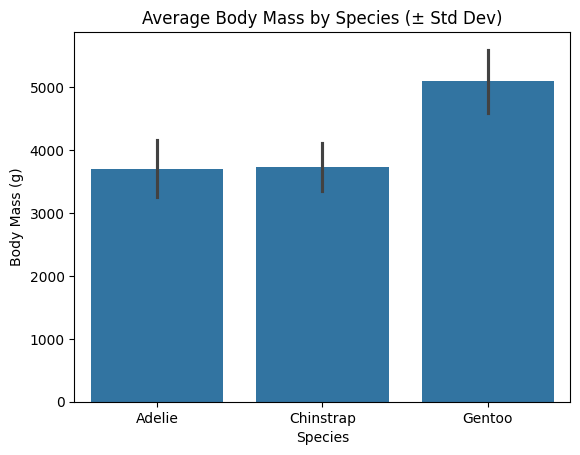

In [17]:
# step2: Show me the visual
sns.barplot(
    data=df,
    x="species",
    y="body_mass_g",
    errorbar="sd"
)

plt.title("Average Body Mass by Species (± Std Dev)")
plt.ylabel("Body Mass (g)")
plt.xlabel("Species")
plt.show()

# observ: Gentoo penguins have a much higher mean body mass.
# The variability, AKA STD_dev, differs somewhat across the 3 species

In [18]:
# step3: compute p_value

from scipy.stats import f_oneway

sample_adelie    = df[df['species'] == 'Adelie']['body_mass_g']
sample_chinstrap = df[df['species'] == 'Chinstrap']['body_mass_g']
sample_gentoo    = df[df['species'] == 'Gentoo']['body_mass_g']
print("sample_adelie   :", list(sample_adelie[:5]))
print("sample_chinstrap:", list(sample_chinstrap[:5]))
print("sample_gentoo   :", list(sample_gentoo[:5]))

f_stat, p_value = f_oneway(sample_adelie, sample_chinstrap, sample_gentoo)

print("f_stat:", f_stat)
print("p_value:", p_value)

sample_adelie   : [3750.0, 3800.0, 3250.0, 3450.0, 3650.0]
sample_chinstrap: [3500.0, 3900.0, 3650.0, 3525.0, 3725.0]
sample_gentoo   : [4500.0, 5700.0, 4450.0, 5700.0, 5400.0]
f_stat: 341.8948949481461
p_value: 3.74450512630046e-81


## What the p-value actually means

### The p-value is the probability (~0% ) of observing a sample mean of Adelie, Chinstrap and Gentoo penguins this different from each other, if they were actually identical.

In [19]:
# step4: Decide

alpha = 0.05

if p_value < alpha:
    print("Reject H0: Body mass differs significantly across species")
else:
    print("Fail to reject H0: No significant difference in body mass")

Reject H0: Body mass differs significantly across species


## Report
Methodology
- We analyzed penguin body mass data grouped by species.
- A statistical test was conducted using a 5% significance level (α = 0.05).

**Average body mass differs significantly** across Adelie, Chinstrap, and Gentoo penguins.

This means the variation in body mass between these species is statistically significant and unlikely to be due to chance.

### Prompt used for AI to generate above code:
```
I have penguin body measurement data. 
sample_adelie    = df[df['species'] == 'Adelie']['body_mass_g']
sample_chinstrap = df[df['species'] == 'Chinstrap']['body_mass_g']
sample_gentoo    = df[df['species'] == 'Gentoo']['body_mass_g']
```

### Problem statement.
Is the difference in average body mass across Adelie, Chinstrap and Gentoo penguins statistically significant ? To answer above question use significance level alpha=0.05

Give me code to answer above question

# Correlation Significance Test
### Question
- Is the relationship between **flipper length and body mass statistically significant** ? To answer above question use **significance level alpha=0.05**.

We are asking whether the observed relationship in the data reflects a real population-level association, or whether it could have occurred by random chance.


### Hypothesis
- **Null hypothesis (H0)**: rho = 0 (no correlation)
- **Alternate hypothesis (H1)**: rho != 0 (there is correlation)

we use simple linear regression (or equivalently, a Pearson correlation test).

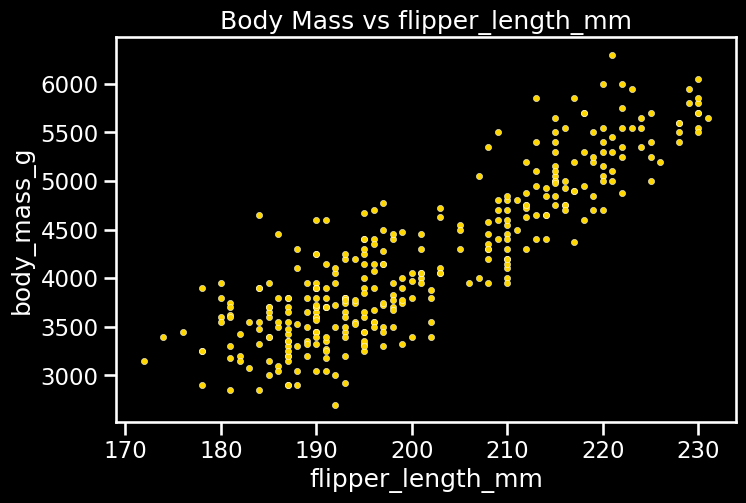

In [13]:
# Step1: Lets use scatter plot

plt.style.use("dark_background")
# Optional: control Seaborn palette and font scale
sns.set_palette(["gold"])
sns.set_context("talk")
plt.figure(figsize=(8,5))

col = 'flipper_length_mm'
# sns.regplot(data=df, x='flipper_length_mm', y='body_mass_g') # Regression line shows trend clearly.
sns.scatterplot(data=df, x="flipper_length_mm", y='body_mass_g', s=20)
plt.title(f'Body Mass vs {col}')
plt.show()

# Observ:
# Upward trend → positive correlation
# Longer flipper length → higher body mass

In [14]:
# step2: find correlation and p_value

from scipy.stats import pearsonr

X = df['flipper_length_mm'] # independant variable
y = df['body_mass_g']       # dependant variable

stat_, p_value = pearsonr(X, y)

print("stat:", stat_)
print("p_value:", p_value)

stat: 0.8729788985653615
p_value: 3.1328362509713565e-105


## What the p-value actually means

### The p-value is the probability (~0% ) of observing a sample having non-zero rho, if there was actually no relation(if H0 was true).

In [22]:
# step3: Decide

alpha = 0.05

if p_value < alpha:
    print("Reject H₀: There is correlation")
else:
    print("Fail to reject H₀: ")

Reject H₀: There is correlation


## Report
At the 5% significance level, there is **strong statistical evidence of a statistically significant linear relationship between flipper length and body mass.**

As flipper length increases, body mass increases on average (penguins with longer flippers tend to be heavier).

# Variance Test

## Question
- Is there a statistically significant difference in body mass **variance** between Adelie and Gentoo penguins? To answer above question use **significance level alpha=0.05**


### Plain-English
Do Adelie and Gentoo penguins show similar variability in body mass?

### Hypothesis
```
- Null Hypothesis (H0)       : Variance of body mass (Adelie) = Variance of body mass (Gentoo)
- Alternative Hypothesis (H1): Variances are different
```

In [23]:
# step1: Find variance

sample_adelie = df[df['species'] == 'Adelie']['body_mass_g']
sample_gentoo = df[df['species'] == 'Gentoo']['body_mass_g']

print("variance for adelie:", sample_adelie.var())
print("variance for gentoo:", sample_gentoo.var())

# observ: The variances look fairly close to each other

variance for adelie: 210332.42796410015
variance for gentoo: 251478.3328585671


In [24]:
# step2: compute p-value

from scipy.stats import levene

sample_adelie = df[df['species'] == 'Adelie']['body_mass_g']
sample_gentoo = df[df['species'] == 'Gentoo']['body_mass_g']

stat_, p_value = levene(sample_adelie, sample_gentoo)

print("stat:", stat_)
print("p_value:", p_value)

stat: 1.9299401700572087
p_value: 0.16594007820292617


## What the p-value actually means

### The p-value is the probability (17% ) of observing a sample variance of Adelie and Gentoo penguins this different from each other, if they were actually identical.

In [25]:
# step3: Decide

alpha = 0.05

if p_value < alpha:
    print("Reject H0: Variance are not equal")
else:
    print("Fail to reject H0: Not enough evidence to reject H0 ")

Fail to reject H0: Not enough evidence to reject H0 


## Report
At the 5% significance level, **there is no statistically significant evidence that the body mass variance differs between Adelie and Gentoo penguins** in this dataset.

In other words, their body mass variability appears statistically similar, even though their mean body mass values are quite different.

# Question
Are male penguins heavier than female penguins?. The sample are given to you in the form of df. Answer this question at significance level alpha=0.05

### Plain English:
Compare average body mass for male vs female penguins.

**Type of test:** Two-sample t-test (difference in means).

### Hypothesis:
- Null Hypothesis (H0)      : Male penguin mean body mass = female penguins mean body mass.
- Alternative Hypothesis(H1): Male penguins have higher mean body mass than female penguins.

In [26]:
# 1) Split into male and female

male   = df[df['sex'] == 'Male']['body_mass_g'].dropna()
female = df[df['sex'] == 'Female']['body_mass_g'].dropna()

In [27]:
# Lets print 1st 5 values of above samples:

print("male  :", male[:5].to_list())
print("female:", female[:5].to_list())

print("mean for male penguins  :", male.mean())
print("mean for female penguins:", female.mean())

male  : [3750.0, 3650.0, 4675.0, 3800.0, 4400.0]
female: [3800.0, 3250.0, 3450.0, 3625.0, 3200.0]
mean for male penguins  : 4545.684523809524
mean for female penguins: 3862.2727272727275


## TODO Write prompt:

In [28]:
# 2) Welch's t-test (does not assume equal variances), one-sided: male > female

from scipy.stats import ttest_ind

statistic, p_two_sided = ttest_ind(male, female, equal_var=False)

print("stat    :", statistic)
print("p-values:", p_two_sided)

stat    : 8.554537231165762
p-values: 4.793891255051508e-16


In [29]:
# 3) Convert to one-sided p-value for alternative: mean_male > mean_female
if statistic > 0:
    p_one_sided = p_two_sided / 2.0
else:
    p_one_sided = 1.0 - p_two_sided / 2.0

In [30]:
# 4) Decide

alpha = 0.05

if p_one_sided < alpha: 
    print("Reject H0: Male penguins are significantly heavier than female penguins")
else:
    print("Fail to reject H0: Not enough evidence to reject H0 ")

Reject H0: Male penguins are significantly heavier than female penguins


# Report
At the 5% significance level, there is very strong statistical evidence that:

**Male penguins are significantly heavier (higher body mass) than female penguins in this dataset.**